In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer

# Machine Learning
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier

# Model tools
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# NLP preprocessing
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [2]:
# Load Fallout dataset
df = pd.read_csv("Fallout.csv")

# View first rows
df.head()

,created_utc,score,domain,id,title,author,ups,downs,num_comments,permalink,...,over_18,thumbnail,subreddit_id,edited,link_flair_css_class,author_flair_css_class,is_self,name,url,distinguished
0,1.358694e+09,2599,imgur.com,16xiw8,This guy.,tingtong70,4160,1561,134,http://www.reddit.com/r/Fallout/comments/16xiw...,...,False,http://a.thumbs.redditmedia.com/7sXllLhygKMAf4...,t5_2qnzu,False,NaN,NaN,False,t3_16xiw8,http://imgur.com/ZzwXnZu,NaN
1,1.363046e+09,2492,imgur.com,1a44y0,I'm playing fallout 3 for the first time. Some...,xerale,3308,816,136,http://www.reddit.com/r/Fallout/comments/1a44y...,...,False,http://d.thumbs.redditmedia.com/GVeFXllOkpfUpt...,t5_2qnzu,False,NaN,NaN,False,t3_1a44y0,http://imgur.com/E0YnW59.jpg,NaN
2,1.353882e+09,2442,i.imgur.com,13s1lo,Note to self: never explore again. Ever.,Svelemoe,3452,1010,221,http://www.reddit.com/r/Fallout/comments/13s1l...,...,False,http://a.thumbs.redditmedia.com/0TRh1pLwMBd_7f...,t5_2qnzu,False,NaN,NaN,False,t3_13s1lo,http://i.imgur.com/1oSDs.jpg,NaN
3,1.360879e+09,2368,imgur.com,18jiaf,This always confused me upon my return to vaul...,ASTROPOPE,3879,1511,160,http://www.reddit.com/r/Fallout/comments/18jia...,...,False,http://a.thumbs.redditmedia.com/Q235qYReprHRXT...,t5_2qnzu,False,NaN,NaN,False,t3_18jiaf,http://imgur.com/0U2Rpt9,NaN
4,1.372194e+09,2252,imgur.com,1h2ao2,Someone made a mod for Fallout NV that only ad...,Lordpwner,4122,1870,168,http://www.reddit.com/r/Fallout/comments/1h2ao...,...,False,http://c.thumbs.redditmedia.com/xpGptK36MP3cqj...,t5_2qnzu,False,NaN,NaN,False,t3_1h2ao2,http://imgur.com/Xshdm,NaN


In [3]:
# Dataset info
df.info()

# Missing values
df.isnull().sum()

# Basic statistics
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   created_utc             1000 non-null   float64
 1   score                   1000 non-null   int64  
 2   domain                  1000 non-null   str    
 3   id                      1000 non-null   str    
 4   title                   1000 non-null   str    
 5   author                  977 non-null    str    
 6   ups                     1000 non-null   int64  
 7   downs                   1000 non-null   int64  
 8   num_comments            1000 non-null   int64  
 9   permalink               1000 non-null   str    
 10  selftext                15 non-null     str    
 11  link_flair_text         0 non-null      float64
 12  over_18                 1000 non-null   bool   
 13  thumbnail               1000 non-null   str    
 14  subreddit_id            1000 non-null   str    
 15 

,created_utc,score,ups,downs,num_comments,link_flair_text,link_flair_css_class,author_flair_css_class,distinguished
count,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,0.0,0.0,0.0,0.0
mean,1.358001e+09,841.091000,1139.023000,297.932000,75.585000,NaN,NaN,NaN,NaN
std,1.284094e+07,374.896749,615.737946,265.931117,83.995011,NaN,NaN,NaN,NaN
min,1.318429e+09,423.000000,472.000000,33.000000,7.000000,NaN,NaN,NaN,NaN
25%,1.347706e+09,551.750000,693.750000,136.000000,34.750000,NaN,NaN,NaN,NaN
50%,1.359928e+09,742.500000,961.500000,216.000000,55.000000,NaN,NaN,NaN,NaN
75%,1.368800e+09,1037.250000,1402.000000,357.000000,85.000000,NaN,NaN,NaN,NaN
max,1.376596e+09,2599.000000,5174.000000,3025.000000,1367.000000,NaN,NaN,NaN,NaN


In [5]:
df.head()

,created_utc,score,domain,id,title,author,ups,downs,num_comments,permalink,...,over_18,thumbnail,subreddit_id,edited,link_flair_css_class,author_flair_css_class,is_self,name,url,distinguished
0,1.358694e+09,2599,imgur.com,16xiw8,This guy.,tingtong70,4160,1561,134,http://www.reddit.com/r/Fallout/comments/16xiw...,...,False,http://a.thumbs.redditmedia.com/7sXllLhygKMAf4...,t5_2qnzu,False,NaN,NaN,False,t3_16xiw8,http://imgur.com/ZzwXnZu,NaN
1,1.363046e+09,2492,imgur.com,1a44y0,I'm playing fallout 3 for the first time. Some...,xerale,3308,816,136,http://www.reddit.com/r/Fallout/comments/1a44y...,...,False,http://d.thumbs.redditmedia.com/GVeFXllOkpfUpt...,t5_2qnzu,False,NaN,NaN,False,t3_1a44y0,http://imgur.com/E0YnW59.jpg,NaN
2,1.353882e+09,2442,i.imgur.com,13s1lo,Note to self: never explore again. Ever.,Svelemoe,3452,1010,221,http://www.reddit.com/r/Fallout/comments/13s1l...,...,False,http://a.thumbs.redditmedia.com/0TRh1pLwMBd_7f...,t5_2qnzu,False,NaN,NaN,False,t3_13s1lo,http://i.imgur.com/1oSDs.jpg,NaN
3,1.360879e+09,2368,imgur.com,18jiaf,This always confused me upon my return to vaul...,ASTROPOPE,3879,1511,160,http://www.reddit.com/r/Fallout/comments/18jia...,...,False,http://a.thumbs.redditmedia.com/Q235qYReprHRXT...,t5_2qnzu,False,NaN,NaN,False,t3_18jiaf,http://imgur.com/0U2Rpt9,NaN
4,1.372194e+09,2252,imgur.com,1h2ao2,Someone made a mod for Fallout NV that only ad...,Lordpwner,4122,1870,168,http://www.reddit.com/r/Fallout/comments/1h2ao...,...,False,http://c.thumbs.redditmedia.com/xpGptK36MP3cqj...,t5_2qnzu,False,NaN,NaN,False,t3_1h2ao2,http://imgur.com/Xshdm,NaN


In [8]:
print(df.columns)

Index(['created_utc', 'score', 'domain', 'id', 'title', 'author', 'ups',
       'downs', 'num_comments', 'permalink', 'selftext', 'link_flair_text',
       'over_18', 'thumbnail', 'subreddit_id', 'edited',
       'link_flair_css_class', 'author_flair_css_class', 'is_self', 'name',
       'url', 'distinguished'],
      dtype='str')


In [12]:
df.columns

Index(['created_utc', 'score', 'domain', 'id', 'title', 'author', 'ups',
       'downs', 'num_comments', 'permalink', 'selftext', 'link_flair_text',
       'over_18', 'thumbnail', 'subreddit_id', 'edited',
       'link_flair_css_class', 'author_flair_css_class', 'is_self', 'name',
       'url', 'distinguished'],
      dtype='str')

In [14]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['created_utc', 'score', 'domain', 'id', 'title', 'author', 'ups',
       'downs', 'num_comments', 'permalink', 'selftext', 'link_flair_text',
       'over_18', 'thumbnail', 'subreddit_id', 'edited',
       'link_flair_css_class', 'author_flair_css_class', 'is_self', 'name',
       'url', 'distinguished'],
      dtype='str')


In [17]:
df.head()
df.columns

Index(['created_utc', 'score', 'domain', 'id', 'title', 'author', 'ups',
       'downs', 'num_comments', 'permalink', 'selftext', 'link_flair_text',
       'over_18', 'thumbnail', 'subreddit_id', 'edited',
       'link_flair_css_class', 'author_flair_css_class', 'is_self', 'name',
       'url', 'distinguished'],
      dtype='str')

In [20]:
df.head()

,created_utc,score,domain,id,title,author,ups,downs,num_comments,permalink,...,over_18,thumbnail,subreddit_id,edited,link_flair_css_class,author_flair_css_class,is_self,name,url,distinguished
0,1.358694e+09,2599,imgur.com,16xiw8,This guy.,tingtong70,4160,1561,134,http://www.reddit.com/r/Fallout/comments/16xiw...,...,False,http://a.thumbs.redditmedia.com/7sXllLhygKMAf4...,t5_2qnzu,False,NaN,NaN,False,t3_16xiw8,http://imgur.com/ZzwXnZu,NaN
1,1.363046e+09,2492,imgur.com,1a44y0,I'm playing fallout 3 for the first time. Some...,xerale,3308,816,136,http://www.reddit.com/r/Fallout/comments/1a44y...,...,False,http://d.thumbs.redditmedia.com/GVeFXllOkpfUpt...,t5_2qnzu,False,NaN,NaN,False,t3_1a44y0,http://imgur.com/E0YnW59.jpg,NaN
2,1.353882e+09,2442,i.imgur.com,13s1lo,Note to self: never explore again. Ever.,Svelemoe,3452,1010,221,http://www.reddit.com/r/Fallout/comments/13s1l...,...,False,http://a.thumbs.redditmedia.com/0TRh1pLwMBd_7f...,t5_2qnzu,False,NaN,NaN,False,t3_13s1lo,http://i.imgur.com/1oSDs.jpg,NaN
3,1.360879e+09,2368,imgur.com,18jiaf,This always confused me upon my return to vaul...,ASTROPOPE,3879,1511,160,http://www.reddit.com/r/Fallout/comments/18jia...,...,False,http://a.thumbs.redditmedia.com/Q235qYReprHRXT...,t5_2qnzu,False,NaN,NaN,False,t3_18jiaf,http://imgur.com/0U2Rpt9,NaN
4,1.372194e+09,2252,imgur.com,1h2ao2,Someone made a mod for Fallout NV that only ad...,Lordpwner,4122,1870,168,http://www.reddit.com/r/Fallout/comments/1h2ao...,...,False,http://c.thumbs.redditmedia.com/xpGptK36MP3cqj...,t5_2qnzu,False,NaN,NaN,False,t3_1h2ao2,http://imgur.com/Xshdm,NaN


In [26]:
print(df.columns)

Index(['created_utc', 'score', 'domain', 'id', 'title', 'author', 'ups',
       'downs', 'num_comments', 'permalink', 'selftext', 'link_flair_text',
       'over_18', 'thumbnail', 'subreddit_id', 'edited',
       'link_flair_css_class', 'author_flair_css_class', 'is_self', 'name',
       'url', 'distinguished'],
      dtype='str')


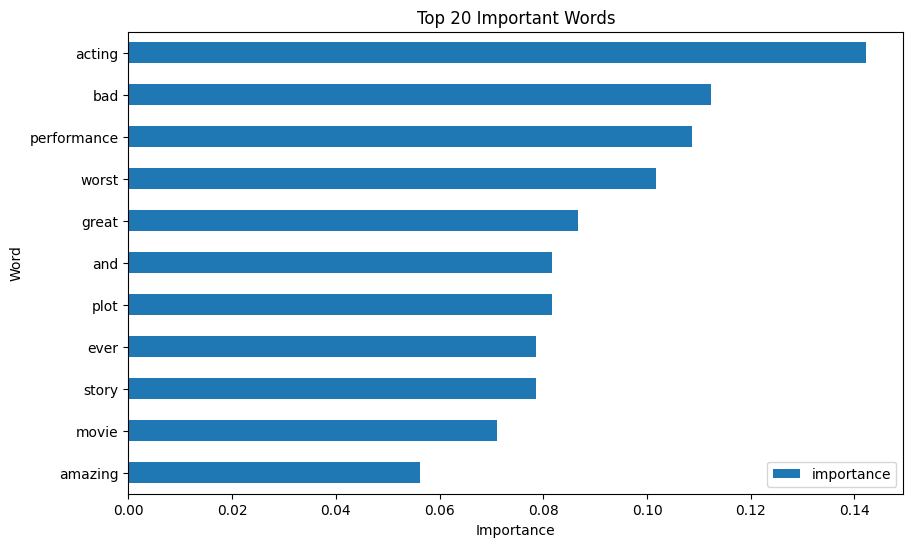

In [35]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier

# Example dataset (replace with your dataset if you already have df)
data = {
    "text": [
        "I love this movie",
        "This film was terrible",
        "Amazing acting and story",
        "Worst movie ever",
        "Great performance",
        "Bad plot and bad acting"
    ],
    "label": [1,0,1,0,1,0]
}

df = pd.DataFrame(data)

# Features and labels
X = df["text"]
y = df["label"]

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Random Forest model
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train_tfidf, y_train)

# Feature importance
importances = rf.feature_importances_
features = tfidf.get_feature_names_out()

feat_df = pd.DataFrame({
    "feature": features,
    "importance": importances
})

top_features = feat_df.sort_values(
    by="importance",
    ascending=False
).head(20)

# Plot
top_features.plot(
    x="feature",
    y="importance",
    kind="barh",
    figsize=(10,6)
)

plt.gca().invert_yaxis()
plt.title("Top 20 Important Words")
plt.xlabel("Importance")
plt.ylabel("Word")

plt.show()